# Problem 1 question 2 - CNN

Mounted at /content/drive
Models will be saved to: /content/drive/MyDrive/models


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/88.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 27000
    })
})
Image shape: (27000, 64, 64, 3)
Label shape: (27000,)
Dataset shapes:
Train images: (17280, 64, 64, 3)
Train labels: (17280,)
Validation images: (4320, 64, 64, 3)
Validation labels: (4320,)
Test images: (5400, 64, 64, 3)
Test labels: (5400,)


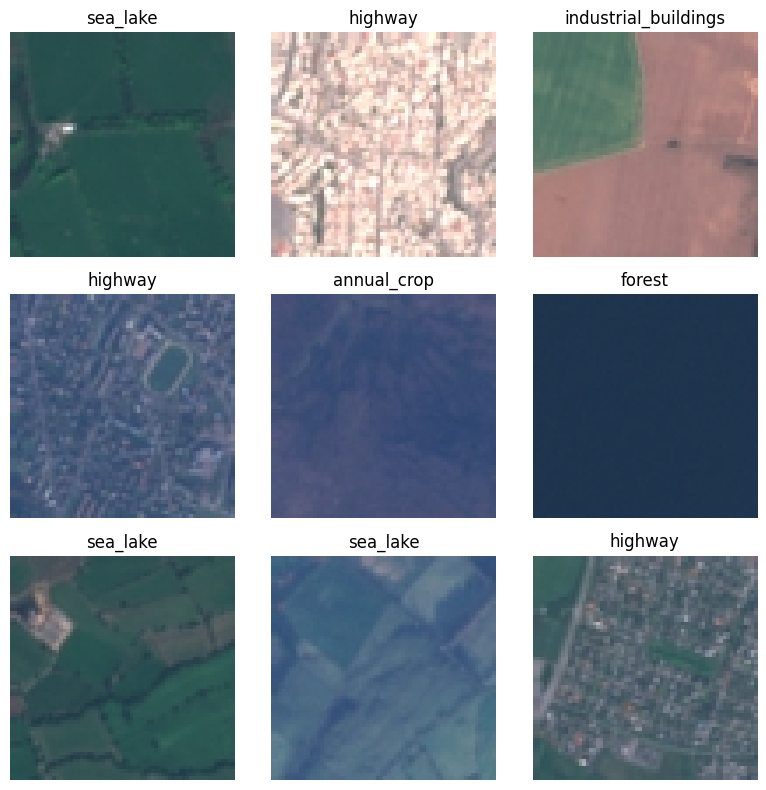

After preprocessing:
Train: (17280, 64, 64, 3)
Validation: (4320, 64, 64, 3)
Test: (5400, 64, 64, 3)

BUILDING BASELINE RESNET50 MODEL
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded - all layers frozen


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_vector (Dense)          │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Training baseline model...
Epoch 1/50
537/540 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7695 - loss: 0.7873
Epoch 1: val_loss improved from inf to 0.28970, saving model to /content/drive/MyDrive/models/resnet50_baseline.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.7700 - loss: 0.7854 - val_accuracy: 0.9044 - val_loss: 0.2897
Epoch 2/50
536/540 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8865 - loss: 0.3453
Epoch 2: val_loss improved from 0.28970 to 0.24933, saving model to /content/drive/MyDrive/models/resnet50_baseline.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8865 - loss: 0.3453 - val_accuracy: 0.9146 - val_loss: 0.2493
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9007 - loss: 0.3045
Epoch 3: val_loss improved from 0.24933 to 0.23035, saving model to /content/drive/MyDrive/models/resnet50_baseline.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9007 - loss: 0.3045 - val_accuracy: 0.9215 - val_loss: 0

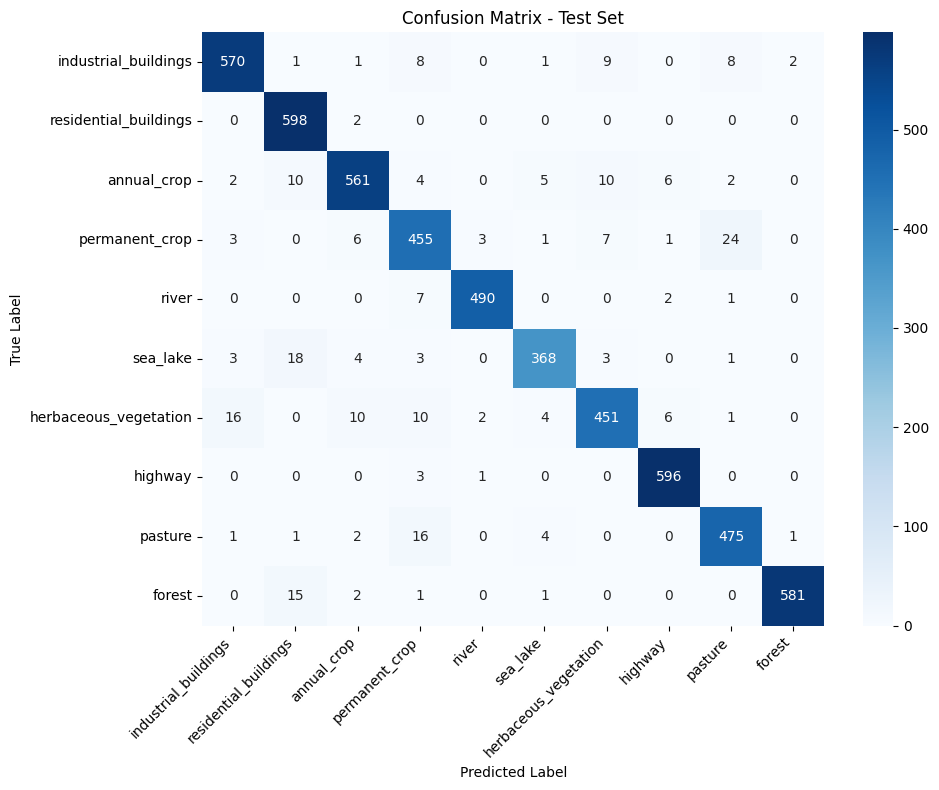


LATENT SPACE INVESTIGATION: PCA vs VAE

Approach A: Extracting features from CNN for PCA...
Feature shape: (17280, 128)
Explained variance ratio: [0.325748   0.13399011]
Total variance explained: 0.4597


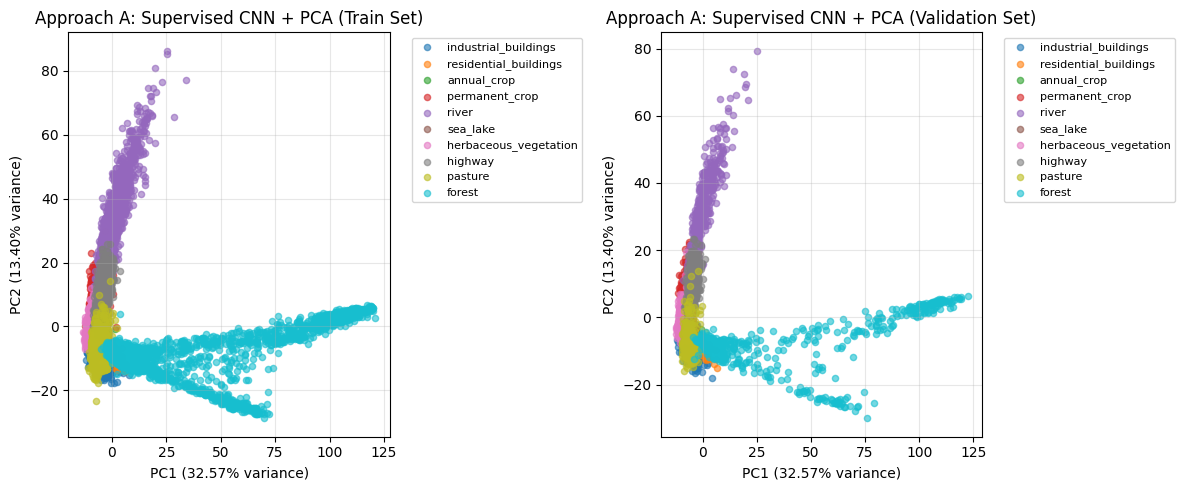


Approach B: Training Variational Autoencoder (VAE)...
Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - kl_loss: 2.4876 - loss: 2642.9917 - reconstruction_loss: 2640.5037 - val_kl_loss: 3.2612 - val_loss: 2577.9927 - val_reconstruction_loss: 2574.7319
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 3.1956 - loss: 2570.1826 - reconstruction_loss: 2566.9861 - val_kl_loss: 3.4107 - val_loss: 2577.6487 - val_reconstruction_loss: 2574.2373
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 3.6684 - loss: 2571.2930 - reconstruction_loss: 2567.6233 - val_kl_loss: 4.1363 - val_loss: 2573.4199 - val_reconstruction_loss: 2569.2834
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 4.1101 - loss: 2569.8088 - reconstruction_loss: 2565.6980 - val_kl_loss: 4.0402 - val_loss: 2573.9075 - val_reconstruction_loss: 2569.8674
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 4.0083 - loss: 2564.9255 - reconstruction_loss: 2560.9172 - val_kl_loss: 

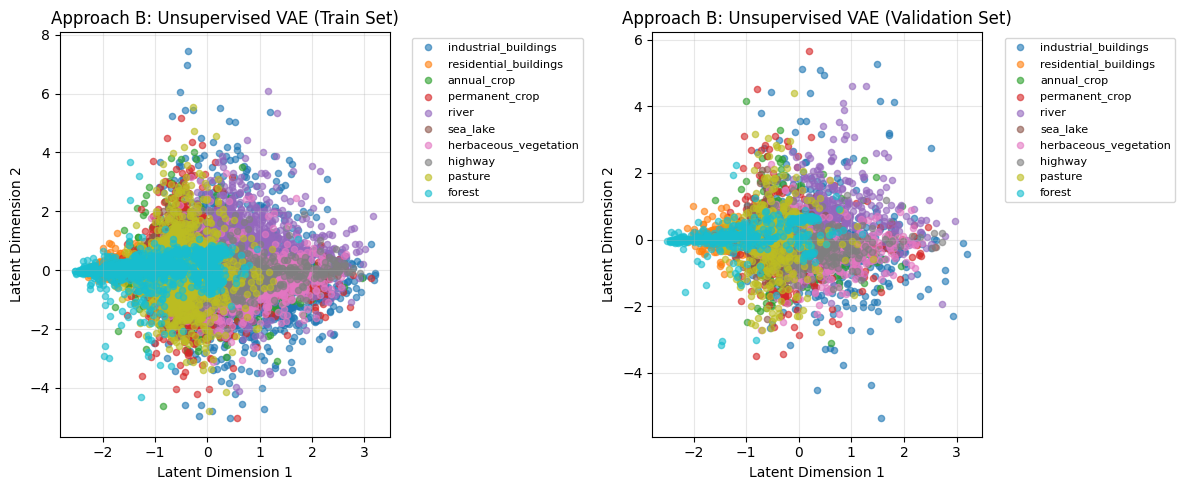


PLOTTING TRAINING HISTORY


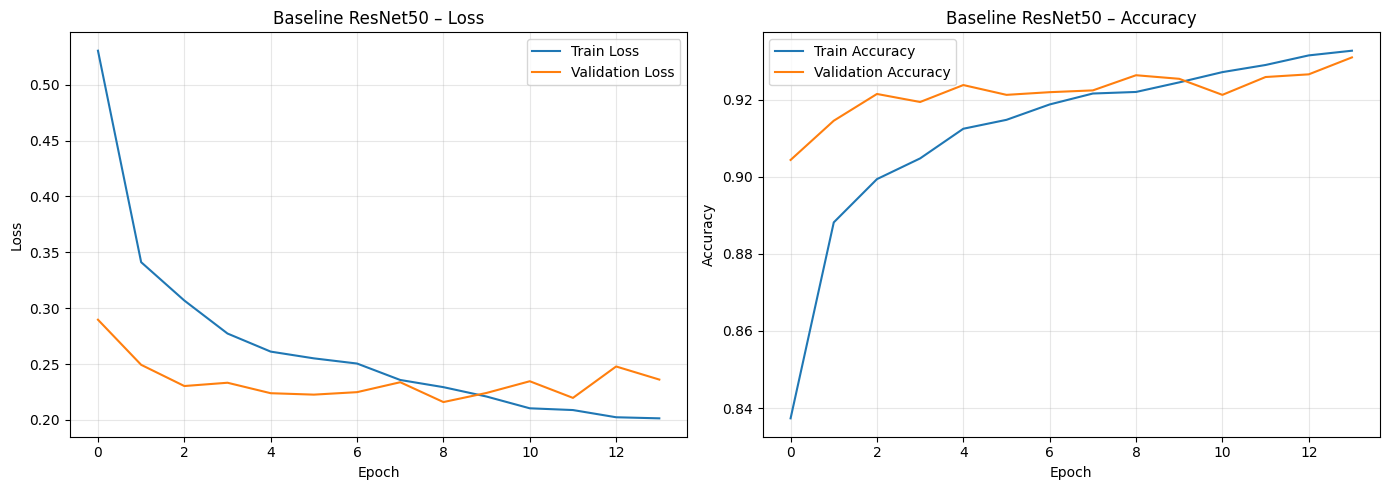

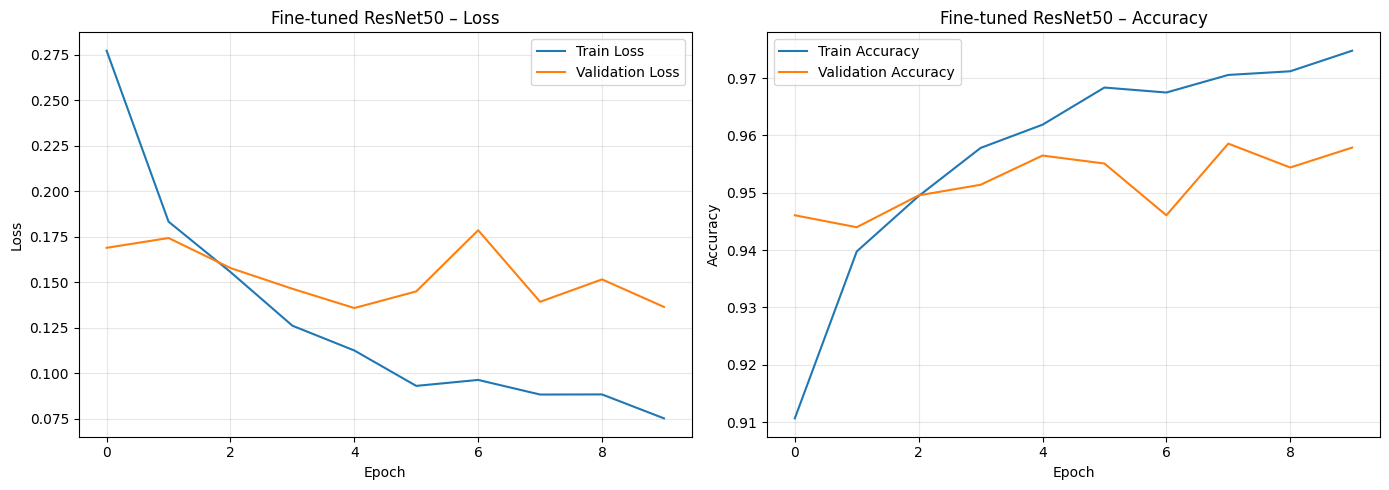

In [ ]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.decomposition import PCA
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from datasets import load_dataset
from tensorflow.keras.applications.resnet50 import preprocess_input
from google.colab import drive
import os
import seaborn as sns

# ===== Mount Google Drive =====
drive.mount('/content/drive')
MODEL_DIR = "/content/drive/MyDrive/models"
os.makedirs(MODEL_DIR, exist_ok=True)
print("Models will be saved to:", MODEL_DIR)

# Load data
ds = load_dataset("nielsr/eurosat-demo")
print(ds)

# Convert images and labels to NumPy arrays
X = np.array(
    [np.array(sample["image"], dtype=np.float32) for sample in ds["train"]]
)
y = np.array(
    [sample["label"] for sample in ds["train"]],
    dtype=np.int32
)
print("Image shape:", X.shape)
print("Label shape:", y.shape)

# First split: 80% full train / 20% test
X_full_train, X_test, y_full_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Second split: 80% train / 20% validation from full train
X_train, X_val, y_train, y_val = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.2,
    stratify=y_full_train,
    random_state=42
)

print(f"Dataset shapes:")
print(f"Train images: {X_train.shape}")
print(f"Train labels: {y_train.shape}")
print(f"Validation images: {X_val.shape}")
print(f"Validation labels: {y_val.shape}")
print(f"Test images: {X_test.shape}")
print(f"Test labels: {y_test.shape}")

class_names = [
    "industrial_buildings", "residential_buildings", "annual_crop",
    "permanent_crop", "river", "sea_lake", "herbaceous_vegetation",
    "highway", "pasture", "forest"
]

# Visualize samples
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].astype(np.uint8))
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Preprocess data
X_train_processed = preprocess_input(X_train.copy())
X_val_processed = preprocess_input(X_val.copy())
X_test_processed = preprocess_input(X_test.copy())

print("After preprocessing:")
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

# ===== MODEL 1: BASELINE RESNET50 =====
print("\n" + "="*60)
print("BUILDING BASELINE RESNET50 MODEL")
print("="*60)

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)
base_model.trainable = False
print("Base model loaded - all layers frozen")

# Data augmentation
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

# Build classification model
inputs = tf.keras.Input(shape=(64, 64, 3))
x = tf.keras.layers.Resizing(224, 224)(inputs)
x = preprocess_input(x)
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu", name="feature_vector")(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model_baseline = Model(inputs=inputs, outputs=outputs)
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_baseline.summary()

# Callbacks for baseline
checkpoint_baseline = ModelCheckpoint(
    os.path.join(MODEL_DIR, "resnet50_baseline.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
callbacks_baseline = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    checkpoint_baseline
]

# Train baseline
print("\nTraining baseline model...")
history_baseline = model_baseline.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_baseline,
    verbose=1
)

# ===== MODEL 2: FINE-TUNED RESNET50 =====
print("\n" + "="*60)
print("FINE-TUNING RESNET50 MODEL")
print("="*60)

# Unfreeze last layers
base_model.trainable = True
frozen_count = 0
for layer in base_model.layers[:-30]:
    layer.trainable = False
    frozen_count += 1

print(f"Frozen layers: {frozen_count}/{len(base_model.layers)}")
print(f"Trainable layers: {len(base_model.layers) - frozen_count}/{len(base_model.layers)}")

# Re-compile for fine-tuning
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks for fine-tuning
checkpoint_finetune = ModelCheckpoint(
    os.path.join(MODEL_DIR, "resnet50_finetuned.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    checkpoint_finetune
]

# Train fine-tuned model
print("\nFine-tuning model...")
history_finetune = model_baseline.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=15,
    batch_size=32,
    callbacks=callbacks_finetune,
    verbose=1
)

# ===== EVALUATION ON TEST SET =====
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

y_pred_probs = model_baseline.predict(X_test_processed)
y_pred = np.argmax(y_pred_probs, axis=1)

test_loss, test_acc = model_baseline.evaluate(X_test_processed, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ===== PART 3: PCA vs VAE COMPARISON =====
print("\n" + "="*60)
print("LATENT SPACE INVESTIGATION: PCA vs VAE")
print("="*60)

# APPROACH A: Supervised PCA
print("\nApproach A: Extracting features from CNN for PCA...")
feature_extractor = Model(
    inputs=model_baseline.input,
    outputs=model_baseline.get_layer("feature_vector").output
)

features_train = feature_extractor.predict(X_train_processed, verbose=0)
features_val = feature_extractor.predict(X_val_processed, verbose=0)

print(f"Feature shape: {features_train.shape}")

# Apply PCA
pca = PCA(n_components=2)
features_2d_train = pca.fit_transform(features_train)
features_2d_val = pca.transform(features_val)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

# Plot PCA
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, class_name in enumerate(class_names):
    mask = y_train == i
    plt.scatter(features_2d_train[mask, 0], features_2d_train[mask, 1],
                label=class_name, alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Approach A: Supervised CNN + PCA (Train Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i, class_name in enumerate(class_names):
    mask = y_val == i
    plt.scatter(features_2d_val[mask, 0], features_2d_val[mask, 1],
                label=class_name, alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Approach A: Supervised CNN + PCA (Validation Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# APPROACH B: Unsupervised VAE
print("\nApproach B: Training Variational Autoencoder (VAE)...")

# VAE components
latent_dim = 2

# Encoder
encoder_inputs = tf.keras.Input(shape=(64, 64, 3))
x = tf.keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = tf.keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)

z_mean = tf.keras.layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = tf.keras.layers.Dense(latent_dim, name="z_log_var")(x)

# Sampling layer
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(8 * 8 * 128, activation="relu")(latent_inputs)
x = tf.keras.layers.Reshape((8, 8, 128))(x)
x = tf.keras.layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = tf.keras.layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# VAE Model
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        """Forward pass through the VAE"""
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        """Validation/test step"""
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(data, reconstruction),
                axis=(1, 2)
            )
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Normalize images for VAE (0-1 range)
X_train_vae = X_train / 255.0
X_val_vae = X_val / 255.0

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

# Train VAE
history_vae = vae.fit(
    X_train_vae,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_vae,),
    verbose=1
)

# Extract VAE latent representations
z_mean_train, _, _ = encoder.predict(X_train_vae, verbose=0)
z_mean_val, _, _ = encoder.predict(X_val_vae, verbose=0)

# Plot VAE latent space
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, class_name in enumerate(class_names):
    mask = y_train == i
    plt.scatter(z_mean_train[mask, 0], z_mean_train[mask, 1],
                label=class_name, alpha=0.6, s=20)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Approach B: Unsupervised VAE (Train Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i, class_name in enumerate(class_names):
    mask = y_val == i
    plt.scatter(z_mean_val[mask, 0], z_mean_val[mask, 1],
                label=class_name, alpha=0.6, s=20)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Approach B: Unsupervised VAE (Validation Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== TRAINING HISTORY PLOTS =====
print("\n" + "="*60)
print("PLOTTING TRAINING HISTORY")
print("="*60)

# Baseline training plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history["loss"], label="Train Loss")
axes[0].plot(history_baseline.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Baseline ResNet50 – Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Baseline ResNet50 – Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Fine-tuning plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_finetune.history["loss"], label="Train Loss")
axes[0].plot(history_finetune.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Fine-tuned ResNet50 – Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_finetune.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_finetune.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Fine-tuned ResNet50 – Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Problem 1 Question 3

PART 1: GRAD-CAM INTERPRETABILITY
Using layer: conv5_block3_out


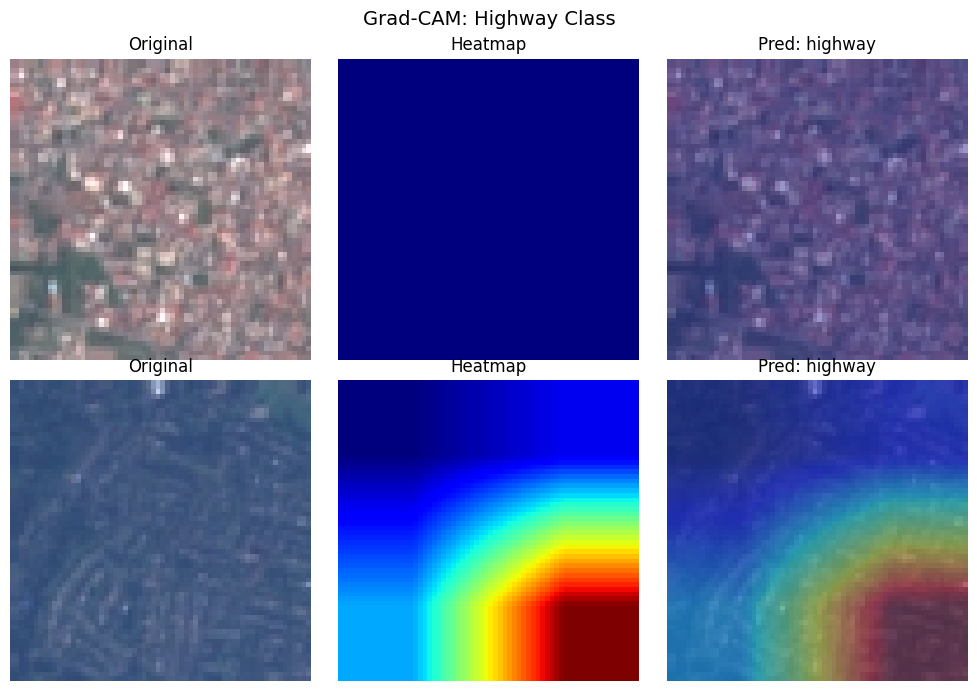

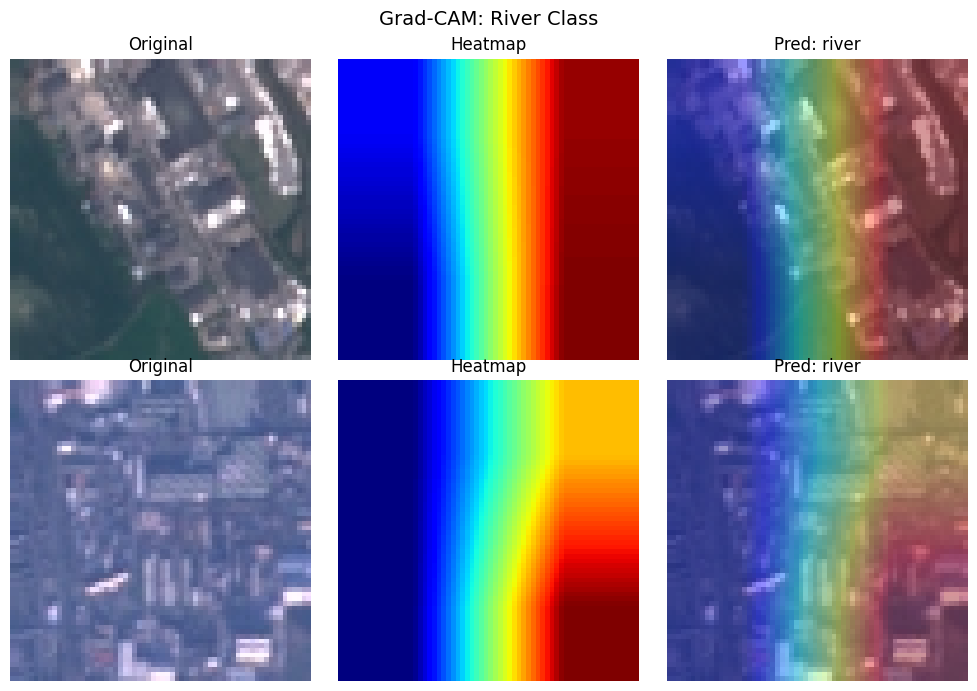


PART 2: MODEL RESILIENCE

Testing Noise:
  Noise σ= 0: Acc = 0.9528
  Noise σ=15: Acc = 0.5250
  Noise σ=30: Acc = 0.1994
  Noise σ=45: Acc = 0.1363
  Noise σ=60: Acc = 0.1174

Testing Blur:
  Blur σ=0: Acc = 0.9528
  Blur σ=1: Acc = 0.4096
  Blur σ=2: Acc = 0.2998
  Blur σ=3: Acc = 0.2648
  Blur σ=4: Acc = 0.2261


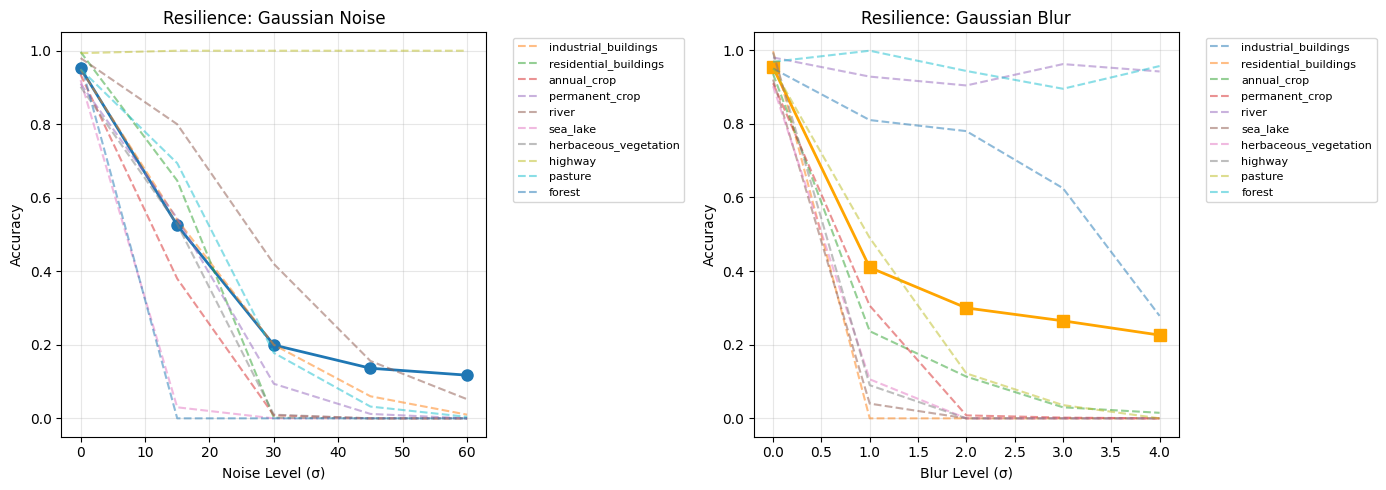


SUMMARY
Baseline accuracy: 0.9528
After max noise: 0.1174 (drop: 83.5%)
After max blur: 0.2261 (drop: 72.7%)

Most fragile classes:
  industrial_buildings     : Noise  94.0% | Blur  67.2%
  residential_buildings    : Noise  99.7% | Blur  99.7%
  annual_crop              : Noise  93.5% | Blur  92.0%
  permanent_crop           : Noise  91.0% | Blur  91.0%
  river                    : Noise  92.8% | Blur   3.8%
  sea_lake                 : Noise  92.0% | Blur  92.0%
  herbaceous_vegetation    : Noise  90.2% | Blur  90.2%
  highway                  : Noise  -0.7% | Blur  99.3%
  pasture                  : Noise  94.6% | Blur  95.0%
  forest                   : Noise  96.8% | Blur   1.2%



In [ ]:
# ===== QUESTION 3: MODEL INTERPRETABILITY AND RESILIENCE =====

# Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score

# ===== PART 1: GRAD-CAM VISUALIZATION =====
print("="*60)
print("PART 1: GRAD-CAM INTERPRETABILITY")
print("="*60)

def make_gradcam_heatmap(img_array, model, pred_index=None):
    """Generate Grad-CAM heatmap"""
    # Get base model
    base_model = model.get_layer('resnet50')

    # Create feature extractor - get output from GlobalAveragePooling
    feature_extractor = tf.keras.Model(
        inputs=model.input,
        outputs=model.get_layer('global_average_pooling2d').output
    )

    # Get last conv layer output separately
    last_conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=base_model.get_layer('conv5_block3_out').output
    )

    # Disable data augmentation during Grad-CAM analysis
    with tf.GradientTape() as tape:
        # Forward pass through data augmentation
        aug_layer = model.get_layer('data_augmentation')
        x = aug_layer(img_array, training=False)

        # Get conv output
        conv_output = last_conv_model(x, training=False)
        tape.watch(conv_output)

        # Continue through model
        x = model.get_layer('global_average_pooling2d')(conv_output)
        x = model.get_layer('feature_vector')(x)
        x = model.get_layer('dropout')(x, training=False)
        predictions = model.layers[-1](x)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Calculate gradients
    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the conv outputs
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Find the ResNet50 base model and its last conv layer
base_model_layer = model_baseline.get_layer('resnet50')
last_conv_layer_name = 'conv5_block3_out'

print(f"Using layer: {last_conv_layer_name}")

# Select samples
highway_idx = class_names.index("highway")
river_idx = class_names.index("river")
highway_samples = np.where(y_test == highway_idx)[0][:2]
river_samples = np.where(y_test == river_idx)[0][:2]

# Visualize Highway
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
fig.suptitle('Grad-CAM: Highway Class', fontsize=14)

for i, idx in enumerate(highway_samples):
    img = X_test[idx].astype(np.uint8)
    img_processed = np.expand_dims(X_test_processed[idx], axis=0)
    heatmap = make_gradcam_heatmap(img_processed, model_baseline)

    # Resize heatmap using TensorFlow
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (64, 64),
        method='bilinear'
    ).numpy().squeeze()

    pred_prob = model_baseline.predict(img_processed, verbose=0)
    pred_class = np.argmax(pred_prob[0])

    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap_resized, cmap='jet')
    axes[i, 1].set_title('Heatmap')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(img)
    axes[i, 2].imshow(heatmap_resized, cmap='jet', alpha=0.4)
    axes[i, 2].set_title(f'Pred: {class_names[pred_class]}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Visualize River
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
fig.suptitle('Grad-CAM: River Class', fontsize=14)

for i, idx in enumerate(river_samples):
    img = X_test[idx].astype(np.uint8)
    img_processed = np.expand_dims(X_test_processed[idx], axis=0)
    heatmap = make_gradcam_heatmap(img_processed, model_baseline)

    # Resize heatmap using TensorFlow
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (64, 64),
        method='bilinear'
    ).numpy().squeeze()

    pred_prob = model_baseline.predict(img_processed, verbose=0)
    pred_class = np.argmax(pred_prob[0])

    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap_resized, cmap='jet')
    axes[i, 1].set_title('Heatmap')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(img)
    axes[i, 2].imshow(heatmap_resized, cmap='jet', alpha=0.4)
    axes[i, 2].set_title(f'Pred: {class_names[pred_class]}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# ===== PART 2: MODEL RESILIENCE =====
print("\n" + "="*60)
print("PART 2: MODEL RESILIENCE")
print("="*60)

def add_noise(images, std):
    """Add Gaussian noise"""
    noise = np.random.normal(0, std, images.shape)
    return np.clip(images + noise, 0, 255)

def add_blur(images, sigma):
    """Add Gaussian blur using TensorFlow"""
    blurred = np.zeros_like(images)
    for i in range(len(images)):
        # Convert to tensor and add batch dimension
        img_tensor = tf.constant(images[i:i+1], dtype=tf.float32)
        # Apply Gaussian blur
        blurred_tensor = tf.nn.depthwise_conv2d(
            img_tensor,
            tf.ones((int(sigma*4)+1, int(sigma*4)+1, 3, 1)) / ((int(sigma*4)+1)**2),
            strides=[1, 1, 1, 1],
            padding='SAME'
        )
        blurred[i] = blurred_tensor.numpy()[0]
    return blurred

# Test noise
noise_levels = [0, 15, 30, 45, 60]
noise_accuracies = []
noise_per_class = {i: [] for i in range(len(class_names))}

print("\nTesting Noise:")
for std in noise_levels:
    X_noisy = add_noise(X_test.copy(), std) if std > 0 else X_test.copy()
    X_noisy_processed = preprocess_input(X_noisy)

    y_pred = np.argmax(model_baseline.predict(X_noisy_processed, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    noise_accuracies.append(acc)

    for i in range(len(class_names)):
        mask = y_test == i
        if np.sum(mask) > 0:
            class_acc = accuracy_score(y_test[mask], y_pred[mask])
            noise_per_class[i].append(class_acc)

    print(f"  Noise σ={std:2d}: Acc = {acc:.4f}")

# Test blur
blur_levels = [0, 1, 2, 3, 4]
blur_accuracies = []
blur_per_class = {i: [] for i in range(len(class_names))}

print("\nTesting Blur:")
for sigma in blur_levels:
    X_blurred = add_blur(X_test.copy(), sigma) if sigma > 0 else X_test.copy()
    X_blurred_processed = preprocess_input(X_blurred)

    y_pred = np.argmax(model_baseline.predict(X_blurred_processed, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    blur_accuracies.append(acc)

    for i in range(len(class_names)):
        mask = y_test == i
        if np.sum(mask) > 0:
            class_acc = accuracy_score(y_test[mask], y_pred[mask])
            blur_per_class[i].append(class_acc)

    print(f"  Blur σ={sigma}: Acc = {acc:.4f}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Noise
axes[0].plot(noise_levels, noise_accuracies, 'o-', linewidth=2, markersize=8)
for i, name in enumerate(class_names):
    axes[0].plot(noise_levels, noise_per_class[i], '--', alpha=0.5, label=name)
axes[0].set_xlabel('Noise Level (σ)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Resilience: Gaussian Noise')
axes[0].legend(bbox_to_anchor=(1.05, 1), fontsize=8)
axes[0].grid(True, alpha=0.3)

# Blur
axes[1].plot(blur_levels, blur_accuracies, 's-', linewidth=2, markersize=8, color='orange')
for i, name in enumerate(class_names):
    axes[1].plot(blur_levels, blur_per_class[i], '--', alpha=0.5, label=name)
axes[1].set_xlabel('Blur Level (σ)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Resilience: Gaussian Blur')
axes[1].legend(bbox_to_anchor=(1.05, 1), fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Baseline accuracy: {noise_accuracies[0]:.4f}")
print(f"After max noise: {noise_accuracies[-1]:.4f} (drop: {(noise_accuracies[0]-noise_accuracies[-1])*100:.1f}%)")
print(f"After max blur: {blur_accuracies[-1]:.4f} (drop: {(blur_accuracies[0]-blur_accuracies[-1])*100:.1f}%)")

print("\nMost fragile classes:")
for i in range(len(class_names)):
    noise_drop = (noise_per_class[i][0] - noise_per_class[i][-1]) * 100
    blur_drop = (blur_per_class[i][0] - blur_per_class[i][-1]) * 100
    print(f"  {class_names[i]:25s}: Noise {noise_drop:5.1f}% | Blur {blur_drop:5.1f}%")

print("\n" + "="*60)